In [26]:
from pathlib import Path
import pandas as pd
import networkx as nx
import numpy as np

In [27]:
BASE_DIR = Path(".")
DATA_DIR = BASE_DIR / "Data"

In [28]:
edges_df = pd.read_parquet(DATA_DIR / "edges_df.parquet")
stations_df = pd.read_parquet(DATA_DIR / "stations_df.parquet")

In [29]:
stations_df.head()

,station_id,station_name,lat,lon
0,1108.0,"North Wharf Road, Paddington",51.518623,-0.176603
1,3447.0,"Gloucester Road (North), Kensington",51.497925,-0.183835
2,1090.0,"Warren Street Station, Euston",51.524438,-0.138019
3,200058.0,"Northdown Street, King's Cross",51.531066,-0.119340
4,1052.0,"Soho Square , Soho",51.515631,-0.132329


In [30]:
edges_df.head()

,start_station_id,start_station_name,end_station_id,end_station_name,weight
0,959,"Milroy Walk, South Bank",959.0,"Milroy Walk, South Bank",296
1,959,"Milroy Walk, South Bank",960.0,"Hop Exchange, The Borough",622
2,959,"Milroy Walk, South Bank",961.0,"Union Street, The Borough",159
3,959,"Milroy Walk, South Bank",962.0,"Stamford Street, South Bank",221
4,959,"Milroy Walk, South Bank",963.0,"Bankside Mix, Bankside",231


In [31]:
graph = nx.from_pandas_edgelist(
    edges_df,
    source="start_station_name",
    target="end_station_name",
    edge_attr="weight",
    create_using=nx.DiGraph()
)

In [32]:
positions = {}

for _, row in stations_df.iterrows():

    positions[row["station_name"]] = (
        row["lon"],
        row["lat"]
    )

In [33]:
station_to_index = {
    station_id: idx
    for idx, station_id in enumerate(
        sorted(stations_df["station_id"].unique())
    )
}

print(station_to_index)

{np.float64(959.0): 0, np.float64(960.0): 1, np.float64(961.0): 2, np.float64(962.0): 3, np.float64(963.0): 4, np.float64(964.0): 5, np.float64(965.0): 6, np.float64(966.0): 7, np.float64(967.0): 8, np.float64(968.0): 9, np.float64(969.0): 10, np.float64(970.0): 11, np.float64(971.0): 12, np.float64(972.0): 13, np.float64(973.0): 14, np.float64(974.0): 15, np.float64(975.0): 16, np.float64(976.0): 17, np.float64(978.0): 18, np.float64(979.0): 19, np.float64(980.0): 20, np.float64(981.0): 21, np.float64(982.0): 22, np.float64(983.0): 23, np.float64(984.0): 24, np.float64(985.0): 25, np.float64(986.0): 26, np.float64(988.0): 27, np.float64(989.0): 28, np.float64(990.0): 29, np.float64(991.0): 30, np.float64(992.0): 31, np.float64(993.0): 32, np.float64(994.0): 33, np.float64(995.0): 34, np.float64(996.0): 35, np.float64(997.0): 36, np.float64(998.0): 37, np.float64(999.0): 38, np.float64(1000.0): 39, np.float64(1001.0): 40, np.float64(1002.0): 41, np.float64(1003.0): 42, np.float64(1004.

In [34]:
index_to_station = {
    idx: station_id
    for station_id, idx in station_to_index.items()
}

print(index_to_station)

{0: np.float64(959.0), 1: np.float64(960.0), 2: np.float64(961.0), 3: np.float64(962.0), 4: np.float64(963.0), 5: np.float64(964.0), 6: np.float64(965.0), 7: np.float64(966.0), 8: np.float64(967.0), 9: np.float64(968.0), 10: np.float64(969.0), 11: np.float64(970.0), 12: np.float64(971.0), 13: np.float64(972.0), 14: np.float64(973.0), 15: np.float64(974.0), 16: np.float64(975.0), 17: np.float64(976.0), 18: np.float64(978.0), 19: np.float64(979.0), 20: np.float64(980.0), 21: np.float64(981.0), 22: np.float64(982.0), 23: np.float64(983.0), 24: np.float64(984.0), 25: np.float64(985.0), 26: np.float64(986.0), 27: np.float64(988.0), 28: np.float64(989.0), 29: np.float64(990.0), 30: np.float64(991.0), 31: np.float64(992.0), 32: np.float64(993.0), 33: np.float64(994.0), 34: np.float64(995.0), 35: np.float64(996.0), 36: np.float64(997.0), 37: np.float64(998.0), 38: np.float64(999.0), 39: np.float64(1000.0), 40: np.float64(1001.0), 41: np.float64(1002.0), 42: np.float64(1003.0), 43: np.float64(1

In [35]:
N = len(stations_df["station_id"].unique())

Wij_matrix = np.zeros((N, N))


for _, row in edges_df.iterrows():

        start_station = row["start_station_id"]
        end_station = row["end_station_id"]
        weight = row["weight"]

        i = station_to_index[start_station]
        j = station_to_index[end_station]


        Wij_matrix[i][j] = weight

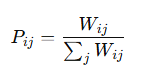

In [36]:
normalization_sum = Wij_matrix.sum(axis=1)
normalization_sum = normalization_sum.reshape((-1, 1))

In [37]:
Pij_matrix = Wij_matrix / normalization_sum

In [38]:
print(Pij_matrix)

[[0.01525695 0.0320602  0.00819545 ... 0.00113396 0.00762847 0.00257719]
 [0.00712542 0.02028331 0.00475501 ... 0.00265429 0.00547891 0.00202975]
 [0.005588   0.02038864 0.0233085  ... 0.00045308 0.00463149 0.00372533]
 ...
 [0.00170948 0.00859122 0.00048216 ... 0.0216972  0.00219164 0.00105199]
 [0.00186766 0.02114461 0.00296825 ... 0.00243463 0.06723586 0.01784285]
 [0.00248139 0.0083871  0.00431762 ... 0.00143921 0.02024814 0.03473945]]


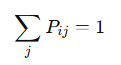

In [39]:
Pij_matrix.sum(axis=1)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1.

In [40]:
p_start_matrix = np.zeros((1, N))
p_start_matrix[0, :] = 1/N
print(p_start_matrix)

[[0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.00124844 0.00124844
  0.00124844 0.00124844 0.00124844 0.00124844 0.

In [41]:
p_start_matrix.shape

(1, 801)

In [42]:
Pij_matrix.shape

(801, 801)

In [43]:
p_current_matrix = np.zeros((1, N))

diff = abs(p_current_matrix - p_start_matrix). sum()
iteration = 0

while diff > 1e-10:
    p_current_matrix = p_start_matrix @ Pij_matrix
    diff = abs(p_current_matrix - p_start_matrix). sum()
    p_start_matrix = p_current_matrix
    iteration += 1

print(iteration)

stationary_distribution = p_current_matrix


78


In [44]:
print(stationary_distribution.sum())

0.9999999999999996


In [45]:
print(stationary_distribution)

[[1.19694307e-03 5.20180163e-03 1.19495217e-03 1.34156917e-03
  1.67731024e-03 1.74637100e-03 1.33896265e-03 1.25083590e-03
  1.16555550e-03 2.44765210e-03 1.18462916e-03 1.01269414e-03
  1.62957351e-03 1.77936267e-03 2.85803667e-03 1.79672063e-03
  1.34723658e-03 7.30692565e-04 1.57601533e-03 1.29073356e-03
  2.43259706e-03 1.71921551e-03 3.24075180e-03 7.56090953e-04
  3.17781444e-03 1.52455422e-03 7.37198256e-04 1.38516439e-03
  9.42258326e-04 7.97599133e-04 3.00247633e-03 6.67856204e-04
  6.71858033e-04 1.65152870e-03 3.27034337e-03 1.24705741e-03
  1.70114616e-03 1.36590774e-03 3.82978978e-03 2.39097427e-03
  8.55440066e-04 1.29155351e-03 1.38425055e-03 1.40728181e-03
  8.56707247e-04 9.14236672e-04 2.47295596e-03 1.79769457e-03
  1.43848336e-03 1.16354013e-03 4.17912381e-03 9.45743310e-04
  8.15039233e-04 9.61768417e-04 1.04957531e-03 1.60303114e-03
  1.53987441e-03 8.90764122e-04 1.51141748e-03 1.62451931e-03
  5.85529009e-04 8.92418322e-04 1.28886000e-03 9.04709259e-04
  1.2330